# Installations and Imports

In [1]:
pip install opencv-python

In [2]:
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import shutil
from zipfile import ZipFile
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import numpy as np
from collections import Counter
from sklearn.model_selection import GridSearchCV

# Crop Type Classifier

## Data Exploration

In [3]:
# Unzip the training data
with ZipFile("train.zip", 'r') as zObject:
    zObject.extractall(
        path="data")

# Unzip the testing data
with ZipFile("test.zip", 'r') as zObject:
    zObject.extractall(
        path="data")

In [4]:
# Show examples training and testing images in array format

img_testy = []

img = cv2.imread('data/train/Apple leaf/20130519yellowingappleleaves.jpg') # Reads in BGR format
img_resized = cv2.resize(img, (128, 128)) # Resize to a consistant size
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY) # Convert the image to gray
img_testy.append(img_gray) # Add the edited image to the array

img = cv2.imread('data/test/Apple leaf/20180511_091133-24l1vhg-e1526047988236.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread("/content/data/train/Apple Scab Leaf/01Apple-scab-2-Venturia-inaequalis.jpg")
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread('/content/data/test/Apple Scab Leaf/052609%20Hartman%20Crabapple%20scab%20single%20leaf.JPG.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img_testy # Print out the pixel values of the four example images

[array([[101, 130, 149, ..., 141, 144, 115],
        [142, 158, 151, ..., 151, 151,  99],
        [149, 153, 149, ..., 150, 131, 101],
        ...,
        [ 75,  90,  62, ..., 125, 112, 112],
        [ 64,  78,  70, ..., 119, 118, 119],
        [ 42,  46,  67, ..., 117, 118, 122]], dtype=uint8),
 array([[ 99, 107, 145, ..., 131, 120, 128],
        [109, 116, 162, ..., 152, 128, 123],
        [121, 138, 144, ..., 168, 156, 139],
        ...,
        [102, 125, 120, ...,  84,  91, 104],
        [105, 120, 119, ..., 108, 113, 116],
        [115, 121, 132, ...,  93, 102,  91]], dtype=uint8),
 array([[121, 143, 156, ..., 117,  94,  61],
        [118, 136, 144, ...,  84,  54,  52],
        [140, 144, 165, ...,  51,  48,  49],
        ...,
        [151, 125, 147, ..., 170, 171, 197],
        [148, 127, 156, ..., 164, 165, 192],
        [157, 155, 159, ..., 155, 166, 181]], dtype=uint8),
 array([[162, 162, 161, ...,  81,  78,  77],
        [161, 162, 161, ...,  76,  82,  78],
        [165, 16

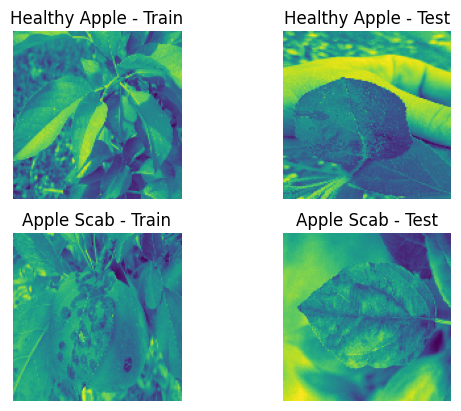

In [5]:
# Add the first image to the figure (top-left position)
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, first position
plt.imshow(img_testy[0])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Apple - Train")

# Add the second image to the figure (top-right position)
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, second position
plt.imshow(img_testy[1])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Apple - Test")

# Add the third image to the figure (bottom-left position)
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, third position
plt.imshow(img_testy[2])
plt.axis('off')  # Hide the axis labels
plt.title("Apple Scab - Train")

# Add the fourth image to the figure (bottom-right position)
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, fourth position
plt.imshow(img_testy[3])
plt.axis('off')  # Hide the axis labels
plt.title("Apple Scab - Test")

plt.show()

## Prepare Data

In [6]:
# function to extract HOG features given the file path of an image
def load_and_extract_features(directory):
    X = []
    y = []
    for label in os.listdir(directory): #loops through each folder in the given directory
      if label.__contains__("Apple") or label.__contains__("Bell_pepper") or label.__contains__("Tomato") or label.__contains__("grape"):
        label_dir = os.path.join(directory, label)
        label_name = label.split()[0]
        for filename in os.listdir(label_dir): # loop through each file in the selected folder
            image_path = os.path.join(label_dir, filename)
            try:
              # Load image using OpenCV
              img = cv2.imread(image_path)
              # Resize image to (128, 128)
              img_resized = cv2.resize(img, (128, 128))
              # Convert image to grayscale
              img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
              # Calculate HOG features
              hog_features = extract_hog_features(img_gray)
              X.append(hog_features)
              y.append(label_name)
            except:
              print(image_path + " - failed\n")
    return X, y

In [7]:
# function to calculate HOG features
def extract_hog_features(image):
    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8),
    cells_per_block=(2, 2), visualize=False)
    return hog_features

In [8]:
# Create the training features and labels
train_X, train_y = load_and_extract_features('data/train')

In [9]:
# Exmaple training element's features
train_X[0]

array([0.24541096, 0.16020394, 0.17833175, ..., 0.03193514, 0.        ,
       0.        ])

In [10]:
# Example training element's label
train_y[0]

'Tomato'

In [11]:
# Number of training elements
len(train_X)

1136

In [12]:
print(np.unique(train_y))

['Apple' 'Bell_pepper' 'Tomato' 'grape']


In [13]:
print(Counter(train_y))

Counter({'Tomato': 671, 'Apple': 240, 'Bell_pepper': 115, 'grape': 110})


In [14]:
test_X, test_y = load_and_extract_features('data/test')

In [15]:
test_X[0]

array([0.32555069, 0.05707976, 0.17910817, ..., 0.11185007, 0.09931767,
       0.        ])

In [16]:
test_y[0]

'Tomato'

In [17]:
len(test_X)

135

In [18]:
print(np.unique(test_y))

['Apple' 'Bell_pepper' 'Tomato' 'grape']


In [19]:
print(Counter(test_y))

Counter({'Tomato': 69, 'Apple': 29, 'grape': 20, 'Bell_pepper': 17})


## Train and Test Model

In [20]:
rf_classifier = RandomForestClassifier(n_estimators=500, max_features="sqrt", criterion='entropy', max_depth=7)
rf_classifier.fit(train_X, train_y)

RandomForestClassifier(criterion='entropy', max_depth=7, n_estimators=500)

In [21]:
y_pred = rf_classifier.predict(test_X)
rf_accuracy = accuracy_score(test_y, y_pred)

print(classification_report(y_pred, test_y))

              precision    recall  f1-score   support

       Apple       0.28      0.50      0.36        16
 Bell_pepper       0.00      0.00      0.00         0
      Tomato       1.00      0.58      0.73       119
       grape       0.00      0.00      0.00         0

    accuracy                           0.57       135
   macro avg       0.32      0.27      0.27       135
weighted avg       0.91      0.57      0.69       135



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
print(y_pred)

['Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Apple' 'Tomato' 'Tomato' 'Tomato' 'Apple' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Apple' 'Apple' 'Tomato' 'Apple' 'Tomato' 'Tomato' 'Apple' 'Tomato'
 'Apple' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Apple' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Apple' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomato'
 'Tomato' 'Apple' 'Tomato' 'Tomato' 'Tomato' 'Tomato' 'Tomat

In [25]:
# Define the parameter grid
param_grid = {
    'n_estimators': [300, 500],
    'max_features': ['sqrt'],
    'max_depth': [5, 7],
    'criterion': ['gini', 'entropy']
}

In [26]:
grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid=param_grid)
grid_search.fit(train_X, train_y)
print(grid_search.best_estimator_)

RandomForestClassifier(criterion='entropy', max_depth=7, n_estimators=500)


# Tomato Disease Classifier

## Data Exploration

In [27]:
#show an example training image in array format

img_testy = []

img = cv2.imread('/content/data/train/Tomato leaf/003.JPG.jpg') # Reads in BGR format
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread('/content/data/test/Tomato leaf/1684.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread("/content/data/train/Tomato Early blight leaf/100_46341.jpg")
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread('/content/data/test/Tomato Early blight leaf/100983448.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img_testy

[array([[137,  89, 112, ...,  29,  18,  80],
        [130, 134, 114, ...,  76,  34,  70],
        [130, 132, 124, ...,  69,  53,  44],
        ...,
        [ 67,  64,  79, ...,  82, 105, 122],
        [ 94,  87,  58, ...,  90, 117, 138],
        [ 93, 104,  74, ..., 140, 138, 134]], dtype=uint8),
 array([[197, 198, 197, ..., 194, 195, 191],
        [200, 198, 197, ..., 195, 195, 194],
        [201, 198, 196, ..., 192, 194, 192],
        ...,
        [185, 185, 184, ..., 171, 171, 171],
        [182, 182, 182, ..., 169, 169, 168],
        [182, 182, 180, ..., 168, 168, 167]], dtype=uint8),
 array([[ 35,  40,  44, ..., 206, 210, 210],
        [ 48,  45,  42, ..., 203, 205, 209],
        [ 46,  42,  36, ..., 201, 201, 207],
        ...,
        [ 30,  36,  52, ..., 161, 166, 161],
        [ 34,  36,  56, ..., 154, 170, 109],
        [ 36,  30,  31, ..., 176, 158,  61]], dtype=uint8),
 array([[ 58,  59,  63, ...,  12,  18,  22],
        [ 49,  48,  50, ...,  29,  32,  32],
        [ 49,  4

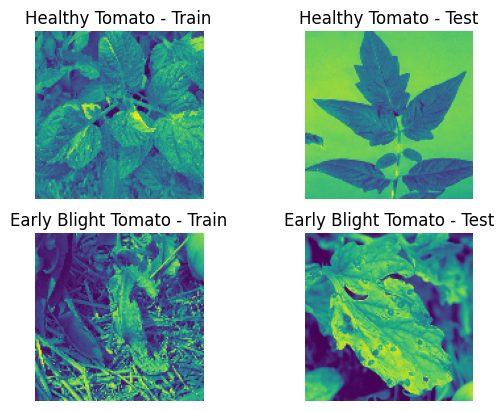

In [28]:
# Add the first image to the figure (top-left position)
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, first position
plt.imshow(img_testy[0])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Tomato - Train")

# Add the second image to the figure (top-right position)
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, second position
plt.imshow(img_testy[1])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Tomato - Test")

# Add the third image to the figure (bottom-left position)
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, third position
plt.imshow(img_testy[2])
plt.axis('off')  # Hide the axis labels
plt.title("Early Blight Tomato - Train")
# Add the fourth image to the figure (bottom-right position)
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, fourth position
plt.imshow(img_testy[3])
plt.axis('off')  # Hide the axis labels
plt.title("Early Blight Tomato - Test")

#plt.imshow(img_gray)
plt.show()

## Prepare Data

In [29]:
# function to extract HOG features given the file path of an image
def load_and_extract_disease_features(directory):
    X = []
    y = []
    for label in os.listdir(directory): #loops through each folder in the given directory
      if label.__contains__("Tomato") :
        label_dir = os.path.join(directory, label)
        label_name_split = label.split()
        if label_name_split[1] == "Early":
          label_name = "Early blight"
        elif label_name_split[1] == "Septoria":
          label_name = "Septoria spot"
        elif label_name_split[1] == "mold":
          label_name = "Mold"
        elif len(label_name_split) == 2:
          label_name = "Healthy"
        elif label_name_split[2] == "bacterial":
          label_name = "Bacterial spot"
        elif label_name_split[2] == "late":
          label_name = "Late blight"
        elif label_name_split[2] == "mosaic":
          label_name = "Mosaic virus"
        elif label_name_split[2] == "yellow":
          label_name = "Yellow virus"
        else:
          label_name = "N/A"
        for filename in os.listdir(label_dir): # loop through each file in the selected folder
            image_path = os.path.join(label_dir, filename)
            # Load image using OpenCV
            img = cv2.imread(image_path)
            # Resize image to (128, 128)
            img_resized = cv2.resize(img, (128, 128))
            # Convert image to grayscale
            img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
            # Calculate HOG features
            hog_features = extract_hog_features(img_gray)
            X.append(hog_features)
            y.append(label_name)
    return X, y

In [30]:
# Create the training features and labels
train_X, train_y = load_and_extract_disease_features('data/train')

In [31]:
# Exmaple training element's features
train_X[0]

array([0.24541096, 0.16020394, 0.17833175, ..., 0.03193514, 0.        ,
       0.        ])

In [32]:
# Example training element's label
train_y[0]

'Septoria spot'

In [33]:
# Number of training elements
len(train_X)

671

In [34]:
print(np.unique(train_y))

['Bacterial spot' 'Early blight' 'Healthy' 'Late blight' 'Mold'
 'Mosaic virus' 'Septoria spot' 'Yellow virus']


In [35]:
print(Counter(train_y))

Counter({'Septoria spot': 139, 'Late blight': 101, 'Bacterial spot': 100, 'Mold': 85, 'Early blight': 78, 'Yellow virus': 70, 'Healthy': 54, 'Mosaic virus': 44})


In [36]:
test_X, test_y = load_and_extract_disease_features('data/test')

In [37]:
test_X[0]

array([0.32555069, 0.05707976, 0.17910817, ..., 0.11185007, 0.09931767,
       0.        ])

In [38]:
test_y[0]

'Septoria spot'

In [39]:
len(test_X)

69

In [40]:
print(np.unique(test_y))

['Bacterial spot' 'Early blight' 'Healthy' 'Late blight' 'Mold'
 'Mosaic virus' 'Septoria spot' 'Yellow virus']


In [41]:
print(Counter(test_y))

Counter({'Septoria spot': 11, 'Late blight': 10, 'Mosaic virus': 10, 'Early blight': 9, 'Bacterial spot': 9, 'Healthy': 8, 'Mold': 6, 'Yellow virus': 6})


## Train and Test Model

TO-DO: Reference Crop Type Classification model to train a random forest model.

TO-DO: Test the model you trained.

TO-DO: Finally, utilize a grid search to tune hyperparameters and then retrain and retest the model to see if it has been improved. Start small with the grid search, it might take a while to run.